# Modelo 2 — Risco de Detrator (NPS ≤ 6)
### Construção passo a passo

**Objetivo:** Identificar, com dados operacionais disponíveis após a entrega,  
quais clientes têm alto risco de dar nota baixa no NPS — **antes** da pesquisa ser enviada.

Isso permite que o SAC entre em contato de forma proativa, revertendo a experiência negativa.

Obs. A base atualmente diponibilizada não traz informações que possibiltem a previsão do atraso na entrega. Entendemos que seria a principal ferramenta para se evitar que o cliente se torne detrator. 

Gatilhos para atraso: 

(Data de entrega prevista x tempo necessário para entrega)
(Quantidade de entregas na data x SLA Contratato)


---
## PASSO 1 — Importar as bibliotecas

Antes de qualquer coisa, precisamos 'chamar' as ferramentas que vamos usar.
Em Python, isso se faz com `import`.

Pense nas bibliotecas como caixas de ferramentas especializadas:
- `pandas` → trabalha com tabelas (DataFrames)
- `numpy` → faz cálculos matemáticos
- `matplotlib` e `seaborn` → criam gráficos estáticos
- `plotly` → cria gráficos interativos
- `sklearn` (scikit-learn) → contém todos os algoritmos de Machine Learning

In [39]:
# Ferramentas de manipulação de dados
import pandas as pd
import numpy as np

# Ferramentas de visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ferramentas de Machine Learning — cada import traz uma função específica
from sklearn.model_selection import train_test_split
# train_test_split → divide os dados em treino e teste

from sklearn.model_selection import cross_val_score, StratifiedKFold
# cross_val_score  → avalia o modelo em múltiplos recortes dos dados
# StratifiedKFold  → define como esses recortes são feitos (mantendo proporção das classes)

from sklearn.linear_model import LogisticRegression
# LogisticRegression → modelo mais simples (baseline de comparação)

from sklearn.ensemble import RandomForestClassifier
# RandomForestClassifier → nosso modelo principal (conjunto de 100 árvores de decisão)

from sklearn.metrics import (
    roc_auc_score,    # AUC: mede se o modelo separa bem as classes (0.5 = sorte, 1.0 = perfeito)
    roc_curve,        # gera os pontos da curva ROC para o gráfico
    f1_score,         # F1: média entre precisão e recall (bom para dados desbalanceados)
    precision_score,  # precisão: dos que o modelo disse 'detrator', quantos realmente eram?
    recall_score,     # recall: dos detratores reais, quantos o modelo encontrou?
    confusion_matrix, # matriz de confusão: tabela de acertos e erros
    classification_report  # relatório completo com todas as métricas
)

import warnings
warnings.filterwarnings('ignore')  # suprime avisos técnicos que não afetam o resultado

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## PASSO 2 — Carregar e inspecionar os dados

`pd.read_csv()` lê o arquivo CSV e transforma em um DataFrame (tabela).  
O `r` antes do caminho evita erros com barras invertidas no Windows (`\` vira `\n` sem ele).

Depois de carregar, sempre vale confirmar:
- Quantas linhas e colunas temos?
- Os tipos de dados estão certos?
- Tem valores nulos?

In [40]:
# Carrega o CSV em um DataFrame chamado 'df'
# Ajuste o caminho conforme onde o arquivo está salvo no seu computador
CAMINHO_CSV = '../data/raw/desafio_nps_fase_1.csv'

df = pd.read_csv(CAMINHO_CSV)

# .shape retorna uma tupla (linhas, colunas) — boa prática sempre conferir ao carregar
n_linhas, n_colunas = df.shape
print(f'Base carregada: {n_linhas} clientes × {n_colunas} variáveis')

Base carregada: 2500 clientes × 19 variáveis


In [41]:
# Visualiza as primeiras linhas para confirmar que o arquivo carregou corretamente
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [42]:
# Verifica se tem valores nulos em alguma coluna
# Valores nulos podem quebrar o modelo se não forem tratados antes
qtd_nulos = df.isnull().sum().sum()
print(f'Total de valores nulos na base: {qtd_nulos}')

Total de valores nulos na base: 0


---
## PASSO 3 — Criar a variável-alvo (target)

**O que é a variável-alvo?**  
É a coluna que o modelo vai tentar prever. No nosso caso, queremos prever se um cliente vai ser Detrator ou não.

O problema é que `nps_score` é um número contínuo (ex: 3.5, 7.8, 9.1).  
Modelos de classificação precisam de uma resposta binária: **0 ou 1**.

A regra de negócio nos diz: NPS ≤ 6 = Detrator. Então:
- `nps_score <= 6` → 1 (é um detrator)
- `nps_score > 6`  → 0 (não é um detrator)

O `.astype(int)` converte o resultado True/False para 1/0.

In [43]:
# Cria a coluna 'detrator': 1 se NPS <= 6, 0 caso contrário
# (df['nps_score'] <= 6) gera True/False → .astype(int) converte para 1/0
df['detrator'] = (df['nps_score'] <= 6).astype(int)

# Calcula a distribuição: quantos detratores temos na base?
total_detratores = df['detrator'].sum()
pct_detratores = df['detrator'].mean() * 100
pct_nao_detratores = 100 - pct_detratores

print(f'Detratores (NPS <= 6):     {total_detratores} clientes ({pct_detratores:.1f}%)')
print(f'Não-detratores (NPS > 6):  {n_linhas - total_detratores} clientes ({pct_nao_detratores:.1f}%)')
print()

# Aviso automático se os dados estiverem muito desbalanceados
# Desbalanceamento ocorre quando uma classe é muito mais frequente que a outra
# Ex: 90% não-detrator e 10% detrator → o modelo pode simplesmente ignorar a classe menor
if pct_detratores < 30 or pct_detratores > 70:
    print('Aviso: classes desbalanceadas.')
    print('Vamos usar class_weight="balanced" no treinamento para compensar.')
else:
    print('Distribuição equilibrada — boa para o modelo.')

Detratores (NPS <= 6):     1851 clientes (74.0%)
Não-detratores (NPS > 6):  649 clientes (26.0%)

Aviso: classes desbalanceadas.
Vamos usar class_weight="balanced" no treinamento para compensar.


---
## PASSO 4 — Selecionar as features (variáveis de entrada)

**O que são features?**  
São as variáveis que o modelo vai usar para aprender. Pense nelas como as 'pistas' que ele analisa para fazer a previsão.

**Atenção ao Data Leakage (vazamento de dados):**  
Esse é um dos erros mais comuns e mais graves em ML.  
Acontece quando usamos no modelo informações que **não estariam disponíveis no momento real da previsão**.

O Modelo 2 roda **após a entrega e antes do NPS ser coletado**. Então:

| Variável | Usar? | Motivo |
|---|---|---|
| `nps_score` | NÃO | É o próprio alvo — o modelo não pode ver a resposta |
| `csat_internal_score` | NÃO | Score interno derivado do NPS — vazamento |
| `repeat_purchase_30d` | NÃO | Recompra em 30 dias ainda não aconteceu |
| `delivery_delay_days` | SIM | Já sabemos o atraso após a entrega |
| `complaints_count` | SIM | Reclamações já foram registradas |
| `customer_service_contacts` | SIM | Contatos com SAC já aconteceram |
| `resolution_time_days` | SIM | Tempo de resolução já é conhecido |

In [44]:
# Lista de features para o Modelo 2
# Inclui apenas variáveis disponíveis APÓS a entrega e ANTES do NPS ser coletado
FEATURES = [
    'delivery_delay_days',       # dias de atraso na entrega
    'complaints_count',          # número de reclamações registradas
    'customer_service_contacts', # número de contatos com o SAC
    'resolution_time_days',      # tempo para resolver os problemas (em dias)
    'delivery_attempts',         # quantas tentativas de entrega foram feitas
    'freight_value',             # valor do frete
    'order_value',               # valor total do pedido
    'items_quantity',            # quantidade de itens no pedido
    'discount_value',            # desconto aplicado
    'customer_tenure_months',    # há quanto tempo o cliente está na empresa
    'payment_installments'       # número de parcelas do pagamento
]

# X = matriz de features (entradas do modelo)
# y = vetor target (saída que o modelo vai aprender a prever)
X = df[FEATURES]  # seleciona apenas as colunas listadas acima
y = df['detrator']  # coluna que criamos no passo anterior

print(f'X (features): {X.shape[0]} linhas × {X.shape[1]} variáveis')
print(f'y (target):   {y.shape[0]} valores (0 ou 1)')
print()
print('Features selecionadas e correlação com o target (detrator):')

# Mostra a correlação de cada feature com o target para confirmar que fazem sentido
# Correlação negativa forte = quando a variável sobe, o risco de detrator cai (ex: recompra)
# Correlação positiva forte = quando a variável sobe, o risco de detrator sobe (ex: atraso)
corr_com_target = X.corrwith(y).sort_values(key=abs, ascending=False).round(3)
print(corr_com_target.to_string())

X (features): 2500 linhas × 11 variáveis
y (target):   2500 valores (0 ou 1)

Features selecionadas e correlação com o target (detrator):
complaints_count             0.447
delivery_delay_days          0.403
customer_service_contacts    0.240
resolution_time_days         0.150
order_value                 -0.031
delivery_attempts           -0.026
freight_value                0.026
items_quantity               0.024
payment_installments        -0.019
customer_tenure_months       0.012
discount_value              -0.007


---
## PASSO 5 — Dividir os dados em treino e teste

**Por que dividir?**  
Se treinarmos e avaliarmos o modelo nos mesmos dados, é como dar o gabarito antes da prova.  
O modelo vai 'decorar' os exemplos em vez de aprender o padrão real — isso se chama **overfitting**.

A solução: separar uma parte dos dados que o modelo **nunca vai ver durante o treino**,  
e usar essa parte apenas para avaliação final.

**Parâmetros da função `train_test_split`:**
- `test_size=0.2` → 20% dos dados vão para o teste, 80% para o treino
- `random_state=42` → 'semente' para embaralhar os dados sempre da mesma forma (reprodutibilidade)
- `stratify=y` → garante que a proporção de detratores seja igual no treino e no teste

In [45]:
# Divide os dados: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,             # features
    y,             # target
    test_size=0.2, # 20% para teste
    random_state=42, # garante que a divisão seja sempre a mesma ao rodar novamente
    stratify=y     # mantém a proporção de detratores nos dois conjuntos
)

# Confirma a divisão
print('Divisão dos dados:')
print(f'  Treino: {len(X_train)} amostras  ({y_train.mean()*100:.1f}% detratores)')
print(f'  Teste:  {len(X_test)} amostras  ({y_test.mean()*100:.1f}% detratores)')
print()
print('Os % de detratores são próximos nos dois conjuntos? Se sim, o stratify funcionou.')

Divisão dos dados:
  Treino: 2000 amostras  (74.1% detratores)
  Teste:  500 amostras  (74.0% detratores)

Os % de detratores são próximos nos dois conjuntos? Se sim, o stratify funcionou.


---
## PASSO 6 — Treinar os modelos

Vamos treinar dois algoritmos para comparar o desempenho:

**Regressão Logística (baseline):**  
O modelo mais simples para classificação binária. Aprende um 'peso' para cada variável  
e soma tudo para gerar uma probabilidade. Serve como ponto de referência.  
`max_iter=1000` define o número máximo de ajustes internos para encontrar os pesos.

**Random Forest (modelo principal):**  
Cria 100 árvores de decisão, cada uma com uma combinação aleatória de variáveis e dados.  
O resultado final é a votação de todas as árvores. Muito mais robusto que uma única árvore.

**`class_weight='balanced'` — por que usar?**  
Se a base tiver mais não-detratores do que detratores, o modelo tende a ignorar a classe menor  
(afinal, errar sempre para o lado maior já garante uma 'boa' acurácia geral).  
Com `balanced`, ele compensa automaticamente dando mais peso às amostras da classe minoritária.

In [46]:
# MODELO A: Regressão Logística (baseline)
# Pensa como: "qual combinação linear das variáveis melhor separa detrator de não-detrator?"
lr = LogisticRegression(
    max_iter=1000,           # máximo de iterações internas para convergir
    class_weight='balanced', # compensa desbalanceamento de classes
    random_state=42          # reprodutibilidade
)

# .fit() é o treinamento — o modelo aprende os padrões dos dados de treino
# Nunca chame .fit() com X_test — seria dar o gabarito!
lr.fit(X_train, y_train)

# .predict() retorna a classe prevista (0 ou 1) para cada amostra de teste
y_pred_lr = lr.predict(X_test)

# .predict_proba() retorna a PROBABILIDADE de cada classe
# [:, 1] pega só a probabilidade da classe 1 (detrator)
# Isso é mais útil que o 0/1 porque permite criar limiares de alerta (ex: prob > 0.7 = risco alto)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Regressão Logística treinada!')

Regressão Logística treinada!


In [47]:
# MODELO B: Random Forest (modelo principal)
# Pensa como: "100 árvores de decisão votando juntas"
# Cada árvore usa uma amostra e um subconjunto de features diferentes (daí o 'random')
rf = RandomForestClassifier(
    n_estimators=100,        # número de árvores na floresta
    class_weight='balanced', # compensa desbalanceamento de classes
    random_state=42          # reprodutibilidade
)

# Treinamento — exatamente o mesmo padrão: .fit(treino)
rf.fit(X_train, y_train)

# Previsões
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest treinado!')

Random Forest treinado!


---
## PASSO 7 — Avaliar os modelos (métricas)

Agora avaliamos com os dados de **teste** — aqueles que o modelo nunca viu.

**As quatro métricas principais:**

- **AUC-ROC:** Mede o poder discriminativo do modelo (0.5 = sorte, 1.0 = perfeito). É a mais importante para comparar modelos.
- **Recall:** Dos detratores reais, quantos o modelo identificou? É nossa prioridade — perder um detrator é pior que um alarme falso.
- **Precisão:** Dos que o modelo apontou como detratores, quantos realmente eram? Afeta o custo operacional do SAC.
- **F1-Score:** Média harmônica entre precisão e recall. Equilibra as duas.

In [48]:
# Calcula as métricas para os dois modelos
auc_lr  = roc_auc_score(y_test, y_prob_lr)  # usa probabilidade, não 0/1
auc_rf  = roc_auc_score(y_test, y_prob_rf)

f1_lr   = f1_score(y_test, y_pred_lr)       # usa previsão 0/1
f1_rf   = f1_score(y_test, y_pred_rf)

prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)

rec_lr  = recall_score(y_test, y_pred_lr)
rec_rf  = recall_score(y_test, y_pred_rf)

# Exibe comparativo — todos os valores calculados pelo código, sem hardcode
print('Comparativo de métricas nos dados de teste:')
print(f'{"Métrica":20s}  {"Reg. Logística":>16s}  {"Random Forest":>14s}')
print('-' * 56)
print(f'{"AUC-ROC":20s}  {auc_lr:>16.3f}  {auc_rf:>14.3f}')
print(f'{"F1-Score":20s}  {f1_lr:>16.3f}  {f1_rf:>14.3f}')
print(f'{"Precisão":20s}  {prec_lr:>16.3f}  {prec_rf:>14.3f}')
print(f'{"Recall":20s}  {rec_lr:>16.3f}  {rec_rf:>14.3f}')

# Identifica o melhor modelo automaticamente
melhor_modelo = 'Random Forest' if auc_rf >= auc_lr else 'Regressão Logística'
melhor_auc = max(auc_lr, auc_rf)
print()
print(f'Modelo com maior AUC: {melhor_modelo} ({melhor_auc:.3f})')

Comparativo de métricas nos dados de teste:
Métrica                 Reg. Logística   Random Forest
--------------------------------------------------------
AUC-ROC                          0.877           0.871
F1-Score                         0.851           0.889
Precisão                         0.924           0.850
Recall                           0.789           0.932

Modelo com maior AUC: Regressão Logística (0.877)


---
## PASSO 8 — Validação Cruzada

**Por que não basta o teste único?**  
Pode ser que a divisão treino/teste tenha 'caído bem' por sorte.  
A validação cruzada repete o experimento 5 vezes com recortes diferentes, dando uma estimativa mais confiável.

**Como funciona o StratifiedKFold?**  
Divide os dados em 5 partes ('folds'). Em cada rodada, 4 partes são usadas para treinar  
e 1 parte para testar. Ao final temos 5 resultados — calculamos a média e o desvio padrão.

Um desvio padrão baixo (ex: ± 0.02) significa que o modelo é estável — não depende de uma divisão específica.

In [49]:
# Configura a validação cruzada estratificada (mantém proporção de classes em cada fold)
cv = StratifiedKFold(
    n_splits=5,       # divide em 5 partes
    shuffle=True,     # embaralha antes de dividir (evita viés de ordenação)
    random_state=42   # reprodutibilidade
)

# cross_val_score treina e avalia o modelo nas 5 combinações e retorna os 5 scores
# scoring='roc_auc' usa o AUC como métrica de avaliação em cada fold
cv_lr = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc')
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print('Validação cruzada (5 folds) — AUC em cada rodada:')
print()
print(f'Regressão Logística: {[round(v, 3) for v in cv_lr]}')
print(f'  Média: {cv_lr.mean():.3f}  ±  {cv_lr.std():.3f}')
print()
print(f'Random Forest:       {[round(v, 3) for v in cv_rf]}')
print(f'  Média: {cv_rf.mean():.3f}  ±  {cv_rf.std():.3f}')
print()

# Diagnóstico automático do Modelo 2
melhor_cv_auc = max(cv_lr.mean(), cv_rf.mean())
if melhor_cv_auc >= 0.8:
    print(f'AUC {melhor_cv_auc:.3f} na CV — modelo bom, recomendado para piloto com o SAC.')
elif melhor_cv_auc >= 0.65:
    print(f'AUC {melhor_cv_auc:.3f} na CV — modelo aceitável, mas pode ser melhorado.')
else:
    print(f'AUC {melhor_cv_auc:.3f} na CV — abaixo do mínimo útil. Revisar features.')

Validação cruzada (5 folds) — AUC em cada rodada:

Regressão Logística: [0.87, 0.871, 0.884, 0.879, 0.899]
  Média: 0.881  ±  0.011

Random Forest:       [0.857, 0.864, 0.889, 0.86, 0.879]
  Média: 0.870  ±  0.012

AUC 0.881 na CV — modelo bom, recomendado para piloto com o SAC.


---
## PASSO 9 — Gráfico: Curva ROC

A Curva ROC mostra o desempenho do modelo em todos os possíveis limiares de decisão.
- Eixo X: taxa de falsos positivos (alarmes falsos)
- Eixo Y: taxa de verdadeiros positivos (detratores encontrados)

Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo.  
A linha diagonal pontilhada representa um modelo aleatório (AUC = 0.5).

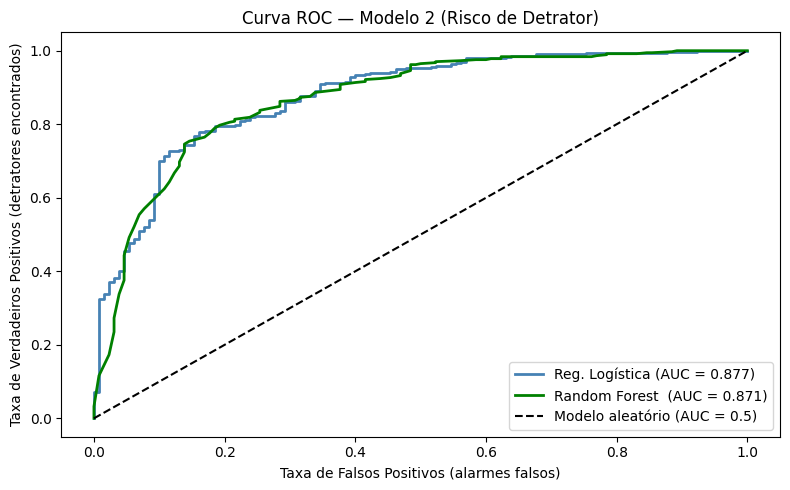

In [50]:
# Calcula os pontos da curva ROC para cada modelo
# roc_curve retorna 3 arrays: taxa de falso positivo, taxa de verdadeiro positivo, e os limiares
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Gráfico
plt.figure(figsize=(8, 5))

# Curva da Regressão Logística
plt.plot(fpr_lr, tpr_lr,
         color='steelblue', lw=2,
         label=f'Reg. Logística (AUC = {auc_lr:.3f})')

# Curva do Random Forest
plt.plot(fpr_rf, tpr_rf,
         color='green', lw=2,
         label=f'Random Forest  (AUC = {auc_rf:.3f})')

# Linha diagonal = modelo que chuta aleatoriamente (referência)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Modelo aleatório (AUC = 0.5)')

plt.xlabel('Taxa de Falsos Positivos (alarmes falsos)')
plt.ylabel('Taxa de Verdadeiros Positivos (detratores encontrados)')
plt.title('Curva ROC — Modelo 2 (Risco de Detrator)')
plt.legend()
plt.tight_layout()
plt.show()

---
## PASSO 10 — Gráfico: Matriz de Confusão

A matriz de confusão detalha onde o modelo acertou e onde errou:

| | Previu: não-detrator | Previu: detrator |
|---|---|---|
| **Real: não-detrator** | Verdadeiro Negativo (VN) ✓ | Falso Positivo (FP) — alarme falso |
| **Real: detrator** | Falso Negativo (FN) — detrator perdido! | Verdadeiro Positivo (VP) ✓ |

No contexto do SAC: o **Falso Negativo** é o erro mais grave.  
Significa que um cliente insatisfeito não foi identificado e não recebeu atenção proativa.

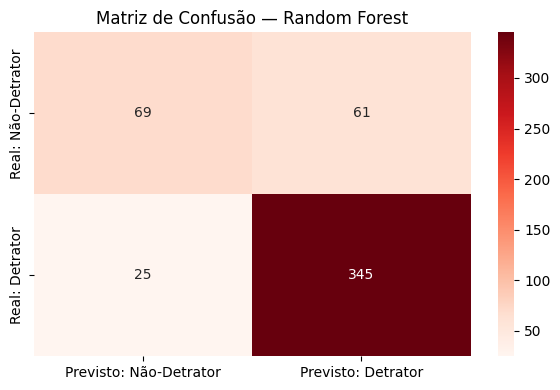

Verdadeiros Positivos  (acertou detrator):       345
Verdadeiros Negativos  (acertou não-detrator):   69
Falsos Positivos       (alarme falso):           61
Falsos Negativos       (perdeu detrator real):   25

Recall do modelo: 345/370 = 93.2% dos detratores reais foram identificados.


In [51]:
# Calcula a matriz de confusão com as previsões do Random Forest (melhor modelo)
cm = confusion_matrix(y_test, y_pred_rf)

# .ravel() desempacota a matriz em 4 valores individuais
tn, fp, fn, tp = cm.ravel()

# Gráfico
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,   # mostra os números dentro das células
    fmt='d',      # formato inteiro (sem decimais)
    cmap='Reds',  # paleta de cores vermelha (mais escuro = mais ocorrências)
    xticklabels=['Previsto: Não-Detrator', 'Previsto: Detrator'],
    yticklabels=['Real: Não-Detrator', 'Real: Detrator']
)
plt.title('Matriz de Confusão — Random Forest')
plt.tight_layout()
plt.show()

# Interpretação em linguagem de negócio
print(f'Verdadeiros Positivos  (acertou detrator):       {tp}')
print(f'Verdadeiros Negativos  (acertou não-detrator):   {tn}')
print(f'Falsos Positivos       (alarme falso):           {fp}')
print(f'Falsos Negativos       (perdeu detrator real):   {fn}')
print()
print(f'Recall do modelo: {tp}/{tp+fn} = {tp/(tp+fn):.1%} dos detratores reais foram identificados.')

---
## PASSO 11 — Gráfico: Importância das Features

O Random Forest nos permite ver quais variáveis foram mais úteis para as previsões.

**`feature_importances_`** é um atributo do modelo treinado que retorna,
para cada feature, qual foi sua contribuição média para reduzir o erro nas 100 árvores.

Isso responde à pergunta: **qual fator mais impacta o risco de um cliente virar Detrator?**

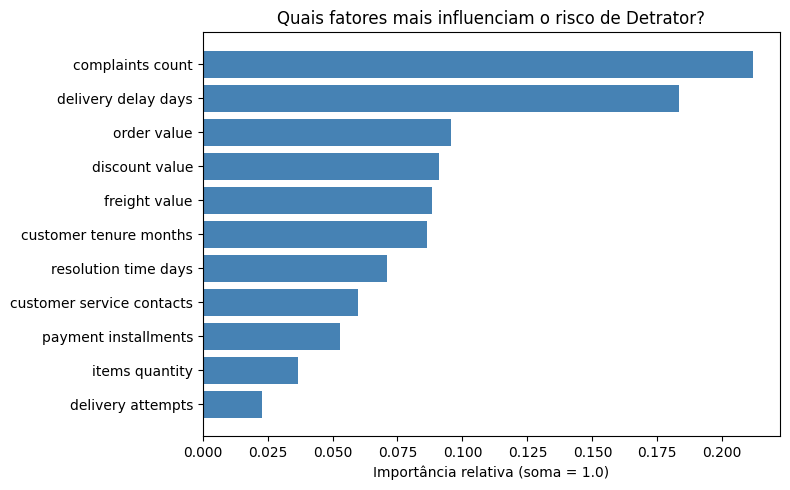

Fator mais importante: complaints count (21.2% de importância)


In [52]:
# Cria um Series com a importância de cada feature, usando os nomes das colunas como índice
importancias = pd.Series(
    rf.feature_importances_,  # array com a importância de cada feature (soma = 1.0)
    index=FEATURES            # usa os nomes das features como rótulos
).sort_values(ascending=True)  # ordena do menor para o maior (para o gráfico horizontal ficar correto)

# Substitui underscores por espaços para melhorar a leitura no gráfico
nomes = [f.replace('_', ' ') for f in importancias.index]

# Gráfico de barras horizontal
plt.figure(figsize=(8, 5))
plt.barh(nomes, importancias.values, color='steelblue')
plt.xlabel('Importância relativa (soma = 1.0)')
plt.title('Quais fatores mais influenciam o risco de Detrator?')
plt.tight_layout()
plt.show()

# Feature mais importante de forma dinâmica
feature_top = importancias.index[-1].replace('_', ' ')
valor_top = importancias.values[-1]
print(f'Fator mais importante: {feature_top} ({valor_top:.1%} de importância)')

---
## PASSO 12 — Sistema de Alertas (aplicação prática)

Aqui transformamos o modelo em algo acionável para o negócio.

Em vez de apenas classificar Detrator/Não-Detrator,  
usamos a **probabilidade** para criar 3 níveis de alerta:

- **ALTO:** contato imediato do SAC
- **MÉDIO:** acompanhamento proativo
- **BAIXO:** fluxo normal

Os limiares são calculados a partir dos dados de treino — não são fixos no código.

In [53]:
# Calcula os limiares de risco com base na distribuição das probabilidades no treino
# np.percentile retorna o valor abaixo do qual X% das amostras estão
# 75º percentil → acima disso = 25% dos clientes com maior risco = alerta ALTO
# 50º percentil → acima disso = metade dos clientes = alerta MÉDIO
scores_treino = rf.predict_proba(X_train)[:, 1]  # probabilidades no conjunto de treino
LIMIAR_ALTO  = float(np.percentile(scores_treino, 75))
LIMIAR_MEDIO = float(np.percentile(scores_treino, 50))

# Função que classifica o risco de cada cliente com base na probabilidade
def classificar_risco(prob):
    if prob >= LIMIAR_ALTO:
        return 'ALTO'
    elif prob >= LIMIAR_MEDIO:
        return 'MEDIO'
    else:
        return 'BAIXO'

# Aplica ao conjunto de teste
df_resultado = X_test.copy()  # cópia para não alterar os dados originais
df_resultado['detrator_real'] = y_test.values  # resultado real (0 ou 1)
df_resultado['prob_detrator'] = y_prob_rf       # probabilidade estimada pelo modelo
df_resultado['nivel_risco']   = df_resultado['prob_detrator'].apply(classificar_risco)

# Agrupa por nível de risco e calcula as estatísticas de cada grupo
resumo = df_resultado.groupby('nivel_risco').agg(
    clientes       = ('prob_detrator', 'count'),      # total de clientes no grupo
    prob_media     = ('prob_detrator', 'mean'),        # probabilidade média
    pct_detratores = ('detrator_real', 'mean')         # % que realmente eram detratores
).round(3)

print(f'Limiares calculados dos dados de treino:')
print(f'  ALTO:  prob >= {LIMIAR_ALTO:.2f}')
print(f'  MÉDIO: prob >= {LIMIAR_MEDIO:.2f}')
print()
print('Resultado por nível de risco (dados de teste):')
print(resumo)

Limiares calculados dos dados de treino:
  ALTO:  prob >= 0.98
  MÉDIO: prob >= 0.93

Resultado por nível de risco (dados de teste):
             clientes  prob_media  pct_detratores
nivel_risco                                      
ALTO               67       0.988           0.955
BAIXO             342       0.647           0.637
MEDIO              91       0.952           0.967


In [54]:
# Gráfico interativo: % de detratores reais por nível de risco
# Este gráfico valida se os níveis de risco fazem sentido:
# o grupo ALTO deve ter a maior % de detratores reais

ordem = ['ALTO', 'MEDIO', 'BAIXO']
cores = {'ALTO': 'red', 'MEDIO': 'orange', 'BAIXO': 'green'}

# Filtra apenas os níveis que existem no resultado
niveis_presentes = [n for n in ordem if n in resumo.index]
pct_por_nivel = resumo.loc[niveis_presentes, 'pct_detratores']

fig = px.bar(
    x=pct_por_nivel.index,
    y=pct_por_nivel.values,
    color=pct_por_nivel.index,
    color_discrete_map=cores,
    width=1000,
    title='% de Detratores Reais por Nível de Risco — validação dos limiares',
    labels={'x': 'Nível de Risco', 'y': '% Detratores Reais'}
)
fig.update_layout(showlegend=False)
fig.update_yaxes(tickformat='.0%', range=[0, 1.1])
fig.show()

---
## PASSO 13 — Sumário Final

Um resumo executivo dos resultados, tudo calculado dinamicamente.

In [71]:
# Extrai informações do grupo de alto risco de forma dinâmica
n_alto = int(resumo.loc['ALTO', 'clientes']) if 'ALTO' in resumo.index else 0
pct_det_alto = float(resumo.loc['ALTO', 'pct_detratores']) if 'ALTO' in resumo.index else 0

# Recall específico dos detratores (classe 1)
report = classification_report(y_test, y_pred_rf, output_dict=True)
recall_detrator = report['1']['recall']

print('SUMÁRIO EXECUTIVO — Modelo 2 (Risco de Detrator)')
print('-' * 55)
print(f'Base analisada:            {n_linhas} clientes')
print(f'Detratores na base:        {total_detratores} ({pct_detratores:.1f}%)')
print()
print(f'Melhor modelo:             {melhor_modelo}')
print(f'AUC no teste:              {melhor_auc:.3f}')
print(f'AUC na validação cruzada:  {max(cv_lr.mean(), cv_rf.mean()):.3f} ± {cv_rf.std():.3f}')
print(f'Recall de detratores:      {recall_detrator:.1%}')
print()
print(f'Sistema de alertas:')
print(f'  Limiar ALTO  (prob >= {LIMIAR_ALTO:.2f}): {n_alto} clientes no teste')
print(f'  Desses, {pct_det_alto:.1%} realmente eram detratores')
print()
print('Como usar na prática:')
print(f'  1. Após a entrega, alimentar o modelo com os dados operacionais')
print(f'  2. Clientes com prob >= {LIMIAR_ALTO:.2f} recebem contato proativo do SAC')
print(f'  3. Pesquisa NPS enviada somente após a resolução, não antes')
print(f'  4. Revalidar o modelo a cada 3-6 meses com dados novos')
print()
print('Limitações importantes:')
print('  - Modelo treinado em dados históricos: degrada se os padrões mudarem')
print('  - Correlação não é causalidade: o modelo identifica padrões, não causas')
print('  - Falsos positivos geram custo operacional: calibrar o limiar com cuidado')


print('Obs: A base atualmente disponibilizada não traz informações que possibilitam a previsão do atraso na entrega.\nEntendemos que seria a principal ferramenta para se evitar que o cliente se torne detrator.')
print('Gatilhos para atraso: ')
print('(Data de entrega prevista x tempo necessário para entrega)')
print('(Quantidade de entregas na data x SLA Contratato)')






SUMÁRIO EXECUTIVO — Modelo 2 (Risco de Detrator)
-------------------------------------------------------
Base analisada:            2500 clientes
Detratores na base:        1851 (74.0%)

Melhor modelo:             Regressão Logística
AUC no teste:              0.877
AUC na validação cruzada:  0.881 ± 0.012
Recall de detratores:      93.2%

Sistema de alertas:
  Limiar ALTO  (prob >= 0.98): 67 clientes no teste
  Desses, 95.5% realmente eram detratores

Como usar na prática:
  1. Após a entrega, alimentar o modelo com os dados operacionais
  2. Clientes com prob >= 0.98 recebem contato proativo do SAC
  3. Pesquisa NPS enviada somente após a resolução, não antes
  4. Revalidar o modelo a cada 3-6 meses com dados novos

Limitações importantes:
  - Modelo treinado em dados históricos: degrada se os padrões mudarem
  - Correlação não é causalidade: o modelo identifica padrões, não causas
  - Falsos positivos geram custo operacional: calibrar o limiar com cuidado
Obs: A base atualmente disp